In [28]:
from ase.build import bulk
from ase.visualize import view
from ase.visualize.plot import plot_atoms
from gpaw import GPAW, PW
from ase.dft.dos import DOS



import nglview as ngv
import matplotlib.pyplot as plt


# Create silicon crystal (diamond cubic structure)
si = bulk('Si', 'diamond', a=5.43)

# Repeat to make it bigger (more visible)
si = si.repeat((2, 2, 2))
si.set_cell(si.cell * 1, scale_atoms=True)

# Visualize
#view(si)

view = ngv.show_ase(si)
view
#plot_atoms(si)
#plt.savefig("structure.png")

NGLWidget()

In [29]:
# Bulk DFT calculation

# calculator
calc = GPAW(
    mode=PW(350),
    kpts=[4, 4, 4], 
    txt='gpaw.bulk_Si.txt'
    #setups={'Si': '11'}
)

si.calc = calc
print(
    'Bulk {0} potential energy = {1:.3f}eV'.format(
        si.get_chemical_formula(), si.get_potential_energy()
    )
)

Timing:                              incl.     excl.
-----------------------------------------------------------
Hamiltonian:                         0.121     0.001   0.0% |
 Atomic:                             0.083     0.001   0.0% |
  XC Correction:                     0.082     0.082   0.0% |
 Calculate atomic Hamiltonians:      0.017     0.017   0.0% |
 Communicate:                        0.000     0.000   0.0% |
 Initialize Hamiltonian:             0.000     0.000   0.0% |
 Poisson:                            0.001     0.001   0.0% |
 XC 3D grid:                         0.019     0.019   0.0% |
LCAO initialization:                 8.212     0.004   0.0% |
 LCAO eigensolver:                   1.312     0.001   0.0% |
  Calculate projections:             0.006     0.006   0.0% |
  DenseAtomicCorrection:             0.013     0.013   0.0% |
  Distribute overlap matrix:         0.000     0.000   0.0% |
  Orbital Layouts:                   0.895     0.895   0.5% |
  Potential matrix:

In [30]:
ground_state_file = 'bulk_Si_groundstate.gpw'
calc.write(ground_state_file)

In [31]:
calc = GPAW(ground_state_file)
dos = DOS(calc, npts=800, width=0)
energies = dos.get_energies()
weights = dos.get_dos()

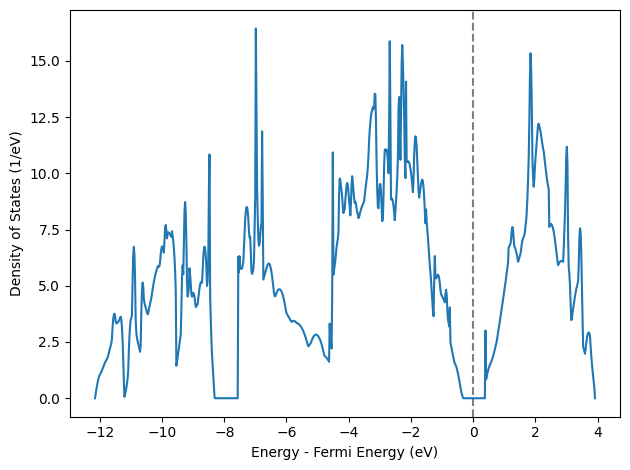

In [32]:
fig, ax = plt.subplots()
ax.axvline(0.0, linestyle='--', color='black', alpha=0.5)
ax.plot(energies, weights)
ax.set_xlabel('Energy - Fermi Energy (eV)')
ax.set_ylabel('Density of States (1/eV)')
fig.tight_layout()

In [33]:
calc = GPAW(ground_state_file)
dos = DOS(calc, npts=800, width=0)
energies = dos.get_energies()
weights = dos.get_dos()

In [34]:
lat = si.cell.get_bravais_lattice()
print(lat.description())

FCC(a=10.86)
  Variant name: FCC
  Special point names: GKLUWX
  Default path: GXWKGLUWLK,UX

  Special point coordinates:
    G   0.0000  0.0000  0.0000
    K   0.3750  0.3750  0.7500
    L   0.5000  0.5000  0.5000
    U   0.6250  0.2500  0.6250
    W   0.5000  0.2500  0.7500
    X   0.5000  0.0000  0.5000



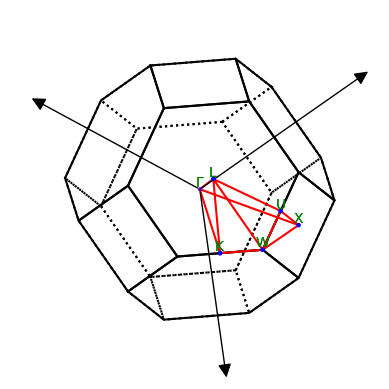

In [35]:
lat.plot_bz(show=True)
plt.show()

In [36]:
path = si.cell.bandpath('WLGXWK', density=10)
path.write('path.json')
print(path)

BandPath(path='WLGXWK', cell=[3x3], special_points={GKLUWX}, kpts=[20x3])


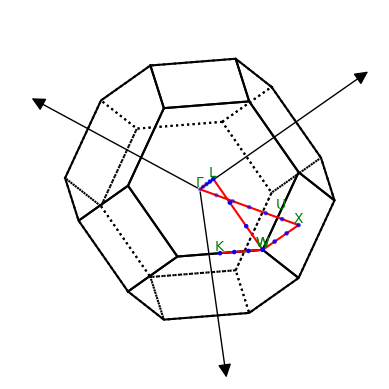

In [37]:
path.plot()
plt.show()

In [38]:
calc = GPAW(ground_state_file)
calc = calc.fixed_density(kpts=path, symmetry='off')


  ___ ___ ___ _ _ _  
 |   |   |_  | | | | 
 | | | | | . | | | | 
 |__ |  _|___|_____|  25.7.0
 |___|_|             

User:   ysafi@YusufSafi
Date:   Thu May  7 13:52:11 2026
Arch:   x86_64
Pid:    15685
CWD:    /mnt/c/UNIVIE/Piezoresistivity-simulations/AEStructure
Python: 3.12.3
gpaw:   /mnt/c/UNIVIE/Piezoresistivity-simulations/wsl_venv/lib/python3.12/site-packages/gpaw
_gpaw:  /mnt/c/UNIVIE/Piezoresistivity-simulations/wsl_venv/lib/python3.12/site-packages/
        _gpaw.cpython-312-x86_64-linux-gnu.so
ase:    /mnt/c/UNIVIE/Piezoresistivity-simulations/wsl_venv/lib/python3.12/site-packages/ase (version 3.28.0)
numpy:  /mnt/c/UNIVIE/Piezoresistivity-simulations/wsl_venv/lib/python3.12/site-packages/numpy (version 2.4.4)
scipy:  /mnt/c/UNIVIE/Piezoresistivity-simulations/wsl_venv/lib/python3.12/site-packages/scipy (version 1.17.1)
libxc:  2.x.y
units:  Angstrom and eV
cores: 1
OpenMP: False
OMP_NUM_THREADS: 1

Input parameters:
  gpts: [35 35 35]
  kpts: {cell: Cell([[0.0, 5.4300000

In [39]:
bs = calc.band_structure()
bs.write('bs.json')
print(bs)

BandStructure(path=BandPath(path='WLGXWK', cell=[3x3], special_points={GKLUWX}, kpts=[20x3]), energies=[1x20x43 values], reference=5.374868676236262)


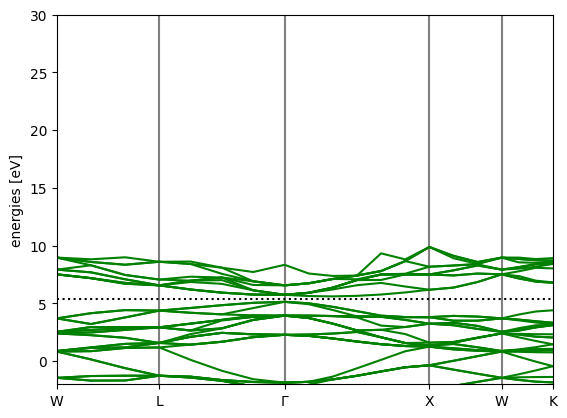

In [40]:
ax = bs.plot()
ax.set_ylim(-2.0, 30.0)
plt.show()